
# Classificação — Grid Search LITE (LogisticRegression, LightGBM, XGBoost)

Reduzimos a busca para **no máximo 3 hiperparâmetros por modelo**, para acelerar a execução.
Também removemos as features vazias solicitadas.


In [21]:
from pathlib import Path
# Caminhos dos dados
DATA_DIR = Path("../data/processed")

# Caminho do arquivo de entrada (ajuste se necessário)
INPUT_CSV = DATA_DIR / r"df_final.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS = 3  # folds do GridSearchCV


In [22]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, RocCurveDisplay, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

from sklearn.linear_model import LogisticRegression

# LightGBM e XGBoost (opcionais)
try:
    import lightgbm as lgb
    HAS_LGBM = True
except Exception as e:
    print("LightGBM não disponível:", e)
    HAS_LGBM = False

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception as e:
    print("XGBoost não disponível:", e)
    HAS_XGB = False

import joblib


In [23]:
# features vazias: "vaga_remuneracao_num","ratio_remuneracao_cand_vaga"
# Lista de features engineered (sem as vazias) + alvo
ENGINEERED = [
    "cand_cidade","cand_uf","cand_regiao","vaga_uf","vaga_cidade_unif","vaga_regiao",
    "same_state","same_city","same_region",
    "meets_academic","meets_english","meets_spanish",
    "sim_tfidf","overlap_kw","jaccard_kw",
    "cand_remuneracao_num",
    "vaga_is_CLT","vaga_is_PJ","vaga_is_Estagiario","vaga_is_Cotas",
    "cand_is_Junior","cand_is_Pleno","cand_is_Senior",
    "vaga_is_Junior","vaga_is_Pleno","vaga_is_Senior",
]
TARGET = "label_contratado"

CATEGORICAL = ["cand_cidade","cand_uf","cand_regiao","vaga_uf","vaga_cidade_unif","vaga_regiao"]
NUMERIC = [c for c in ENGINEERED if c not in CATEGORICAL]


In [24]:
# Load
import pandas as pd
df = pd.read_csv(INPUT_CSV)

missing = [c for c in ENGINEERED + [TARGET] if c not in df.columns]
if missing:
    raise ValueError(f"Colunas ausentes no CSV: {missing}")

X = df[ENGINEERED].copy()
y = df[TARGET].astype(int).copy()

print("Formato X:", X.shape, "| Formato y:", y.shape)
print("Distribuição de y:")
print(y.value_counts(dropna=False))


Formato X: (11264, 26) | Formato y: (11264,)
Distribuição de y:
label_contratado
0    8180
1    3084
Name: count, dtype: int64


In [25]:
# Split e pos_weight
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
pos_weight = n_neg / max(n_pos, 1)
print(f"Treino: pos={n_pos}, neg={n_neg}, scale_pos_weight ~ {pos_weight:.2f}")


Treino: pos=2467, neg=6544, scale_pos_weight ~ 2.65


In [26]:
# Pré-processadores
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold

preproc_lr = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
    ("num", Pipeline(steps=[
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False))
    ]), NUMERIC),
], remainder="drop", sparse_threshold=0.3)

preproc_tree = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
    ("num", SimpleImputer(strategy="median"), NUMERIC),
], remainder="drop", sparse_threshold=0.3)

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


## 1) LogisticRegression — Grid Search (3 hiperparâmetros)

In [27]:
# LR com até 3 hiperparâmetros: penalty, C, l1_ratio
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

# logreg = LogisticRegression(
#     solver="saga", max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE
# )
# pipe_lr = Pipeline(steps=[("pre", preproc_lr), ("clf", logreg)])

# param_grid_lr = [
#     {"clf__penalty":["l2"], "clf__C":[0.5, 1.0, 2.0]},
#     {"clf__penalty":["l1"], "clf__C":[0.5, 1.0, 2.0]},
#     {"clf__penalty":["elasticnet"], "clf__C":[0.5, 1.0, 2.0], "clf__l1_ratio":[0.2, 0.5, 0.8]},
# ]

# gs_lr = GridSearchCV(
#     estimator=pipe_lr,
#     param_grid=param_grid_lr,
#     cv=cv,
#     scoring="roc_auc",
#     n_jobs=-1,
#     verbose=1
# )
# gs_lr.fit(X_train, y_train)
# print("Melhor params LR:", gs_lr.best_params_)
# print("Melhor CV AUC (LR):", gs_lr.best_score_)

# best_lr = gs_lr.best_estimator_
# proba_lr = best_lr.predict_proba(X_test)[:,1]
# auc_lr = roc_auc_score(y_test, proba_lr)
# print("Holdout AUC-ROC (LR): %.4f" % auc_lr)

# y_pred_lr = (proba_lr >= 0.5).astype(int)
# print("\nClassification report (LR, thr=0.5)\n", classification_report(y_test, y_pred_lr, digits=4))
# cm = confusion_matrix(y_test, y_pred_lr)
# ConfusionMatrixDisplay(cm).plot(cmap="Blues"); plt.title("Matriz de Confusão - LR"); plt.tight_layout(); plt.show()

# RocCurveDisplay.from_predictions(y_test, proba_lr)
# plt.title("ROC - LogisticRegression (best)"); plt.tight_layout(); plt.show()


## 2) LightGBM — Grid Search (3 hiperparâmetros)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[LightGBM] [Info] Number of positive: 1645, number of negative: 4362
[LightGBM] [Info] Number of positive: 1644, number of negative: 4363
[LightGBM] [Info] Number of positive: 1645, number of negative: 4362
[LightGBM] [Info] Number of positive: 1645, number of negative: 4363
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008887 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 825
[LightGBM] [Info] Number of data points in the train set: 6007, number of used features: 77
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010027 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 830
[LightGBM] [Info] Number of data points in the train set: 6007, number of used features: 78
[LightGBM] [Info] [binary:

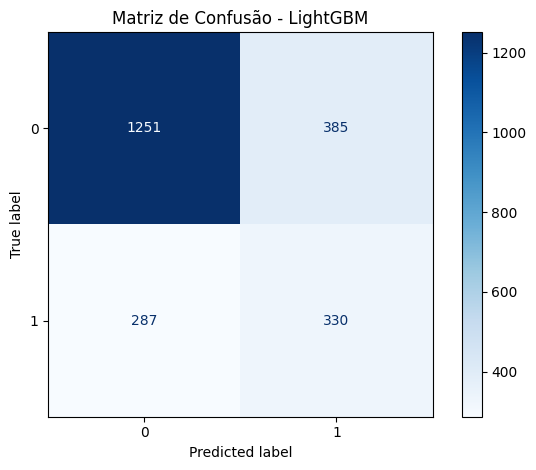

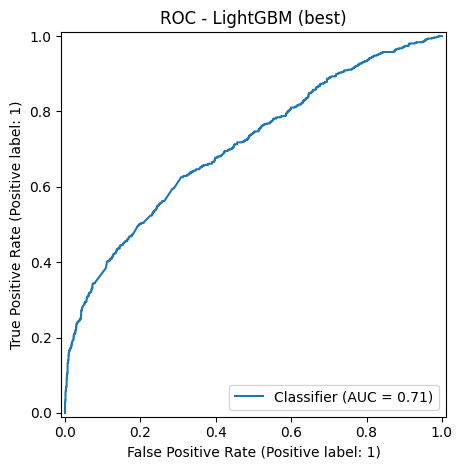

Métricas de teste:
  Acurácia: 0.7017
  Precisão: 0.4615
  Recall: 0.5348
  F1-score: 0.4955
  Matriz de confusão:


In [30]:
# LGBM com até 3 hiperparâmetros: n_estimators, learning_rate, num_leaves
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

if HAS_LGBM:
    lgbm = lgb.LGBMClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        metric="auc",
        scale_pos_weight=pos_weight
    )
    pipe_lgbm = Pipeline(steps=[("pre", preproc_tree), ("clf", lgbm)])

    param_grid_lgbm = {
        "clf__n_estimators":[300, 600],
        "clf__learning_rate":[0.05, 0.1],
        "clf__num_leaves":[31, 63],
    }

    gs_lgbm = GridSearchCV(
        estimator=pipe_lgbm,
        param_grid=param_grid_lgbm,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1
    )
    gs_lgbm.fit(X_train, y_train)
    print("Melhor params LGBM:", gs_lgbm.best_params_)
    print("Melhor CV AUC (LGBM):", gs_lgbm.best_score_)

    best_lgbm = gs_lgbm.best_estimator_
    joblib.dump(best_lgbm, "../models/model_lgbm_nb.joblib")

    proba_lgbm = best_lgbm.predict_proba(X_test)[:,1]
    auc_lgbm = roc_auc_score(y_test, proba_lgbm)
    print("Holdout AUC-ROC (LGBM): %.4f" % auc_lgbm)

    y_pred_lgbm = (proba_lgbm >= 0.5).astype(int)
    print("\nClassification report (LGBM, thr=0.5)\n", classification_report(y_test, y_pred_lgbm, digits=4))
    cm = confusion_matrix(y_test, y_pred_lgbm)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues"); plt.title("Matriz de Confusão - LightGBM"); plt.tight_layout(); plt.show()

    acc = accuracy_score(y_test, y_pred_lgbm)
    prec = precision_score(y_test, y_pred_lgbm, zero_division=0)
    rec = recall_score(y_test, y_pred_lgbm, zero_division=0)
    f1 = f1_score(y_test, y_pred_lgbm, zero_division=0)

    RocCurveDisplay.from_predictions(y_test, proba_lgbm)
    plt.title("ROC - LightGBM (best)"); plt.tight_layout(); plt.show()
    print("Métricas de teste:")
    print(f"  Acurácia: {acc:.4f}")
    print(f"  Precisão: {prec:.4f}")
    print(f"  Recall: {rec:.4f}")
    print(f"  F1-score: {f1:.4f}")
    print("  Matriz de confusão:")
else:
    print("LightGBM não instalado. Para instalar: pip install lightgbm")


## 3) XGBoost — Grid Search (3 hiperparâmetros)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Melhor params XGB: {'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 400}
Melhor CV AUC (XGB): 0.7201233283379213
Holdout AUC-ROC (XGB): 0.7159

Classification report (XGB, thr=0.5)
               precision    recall  f1-score   support

           0     0.8169    0.7744    0.7951      1636
           1     0.4744    0.5397    0.5049       617

    accuracy                         0.7102      2253
   macro avg     0.6456    0.6571    0.6500      2253
weighted avg     0.7231    0.7102    0.7156      2253



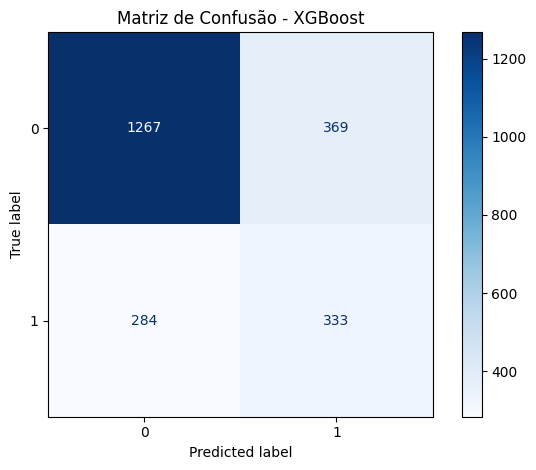

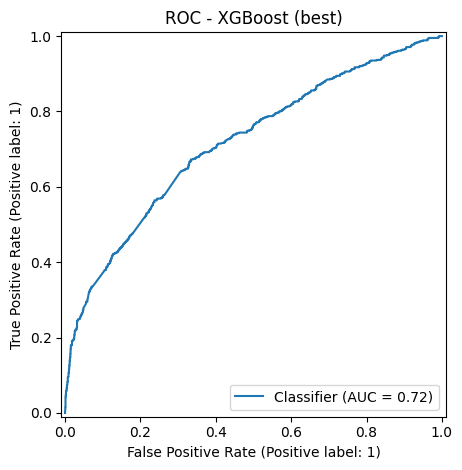

Métricas de teste:
  Acurácia: 0.7102
  Precisão: 0.4744
  Recall: 0.5397
  F1-score: 0.5049
  Matriz de confusão:


In [31]:
# XGB com até 3 hiperparâmetros: n_estimators, learning_rate, max_depth
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

if HAS_XGB:
    xgb_clf = xgb.XGBClassifier(
        random_state=RANDOM_STATE,
        tree_method="hist",
        eval_metric="auc",
        n_jobs=-1,
        scale_pos_weight=pos_weight
    )
    pipe_xgb = Pipeline(steps=[("pre", preproc_tree), ("clf", xgb_clf)])

    param_grid_xgb = {
        "clf__n_estimators":[400, 800],
        "clf__learning_rate":[0.05, 0.1],
        "clf__max_depth":[4, 6],
    }

    gs_xgb = GridSearchCV(
        estimator=pipe_xgb,
        param_grid=param_grid_xgb,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1
    )
    gs_xgb.fit(X_train, y_train)
    print("Melhor params XGB:", gs_xgb.best_params_)
    print("Melhor CV AUC (XGB):", gs_xgb.best_score_)

    best_xgb = gs_xgb.best_estimator_
    proba_xgb = best_xgb.predict_proba(X_test)[:,1]
    auc_xgb = roc_auc_score(y_test, proba_xgb)
    print("Holdout AUC-ROC (XGB): %.4f" % auc_xgb)

    y_pred_xgb = (proba_xgb >= 0.5).astype(int)
    print("\nClassification report (XGB, thr=0.5)\n", classification_report(y_test, y_pred_xgb, digits=4))
    cm = confusion_matrix(y_test, y_pred_xgb)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues"); plt.title("Matriz de Confusão - XGBoost"); plt.tight_layout(); plt.show()

    RocCurveDisplay.from_predictions(y_test, proba_xgb)
    plt.title("ROC - XGBoost (best)"); plt.tight_layout(); plt.show()

    acc = accuracy_score(y_test, y_pred_xgb)
    prec = precision_score(y_test, y_pred_xgb, zero_division=0)
    rec = recall_score(y_test, y_pred_xgb, zero_division=0)
    f1 = f1_score(y_test, y_pred_xgb, zero_division=0)

    print("Métricas de teste:")
    print(f"  Acurácia: {acc:.4f}")
    print(f"  Precisão: {prec:.4f}")
    print(f"  Recall: {rec:.4f}")
    print(f"  F1-score: {f1:.4f}")
    print("  Matriz de confusão:")
else:
    print("XGBoost não instalado. Para instalar: pip install xgboost")
